## Regularization

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# DATASET
df = pd.read_csv("/home/deeps/Desktop/Machine_learning_practice/dataset/Boston_house_prices/housing.csv")


In [4]:
df.shape

(505, 1)

In [5]:
#read the dataset and separate the data into columns
df = pd.read_csv("/home/deeps/Desktop/Machine_learning_practice/dataset/Boston_house_prices/housing.csv", sep=r"\s+")

In [6]:
df.head(5)

,0.00632,18.00,2.310,0,0.5380,6.5750,65.20,4.0900,1,296.0,15.30,396.90,4.98,24.00
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


In [7]:
#set column names
df.columns = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV"
]

In [8]:
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


In [9]:
#divide input and output
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [10]:
#Scale the data
mean = np.mean(X, axis=0)
std = np.std(X,axis=0)
X_scaled = (X-mean) / std

In [11]:
#Unscaled data
X_unscaled = X.copy()

In [12]:
"""add intercept on both scaled and unscaled dataset"""
m = X.shape[0]
X_scaled = np.c_[np.ones((m,1)),X_scaled]
X_unscaled = np.c_[np.ones((m,1)),X_unscaled]

In [13]:
## Split the data into training and test dataset using numpy

# change the y DataFrame to numpy
y = y.to_numpy().reshape(-1,1)

#random permutation
shuffle = np.random.permutation(m)

#put random array in X
X_scaled_shuffle = X_scaled[shuffle]
X_unscaled_shuffle = X_unscaled[shuffle]
y_shuffle = y[shuffle]

#Split the data into 80:20 training-testing data
split = int(0.8*m)

#Scaled train test split
Xsc_train = X_scaled_shuffle[:split]
Xsc_test = X_scaled_shuffle[split:]

#Unscaled train test split
Xuc_train = X_unscaled_shuffle[:split]
Xuc_test = X_unscaled_shuffle[split:]

y_train = y_shuffle[:split]
y_test = y_shuffle[split:]



In [59]:
# ============================================
# Ridge Regularization
# ============================================
def ridge(X_train,error,lmbda,weights,N):
    loss = np.mean((error)**2) + (lmbda * np.sum(weights[1:]**2))
    grad_mse = (2/N) * (X_train.T @ error)
    grad_ridge = np.vstack([0,2*lmbda*weights[1:]]) #avoid reguilarizing bias term
    gradient = grad_mse + grad_ridge
    return loss,gradient

In [60]:
# ============================================
# Lasso Regularization
# ============================================
def lasso(X_train,error,alphav,weights,N):
    loss = np.mean((error)**2) + (alphav * np.sum(np.abs(weights[1:])))
    grad_mse = (2/N) * (X_train.T @ error)
    grad_lasso = np.vstack([0,alphav *np.sign(weights[1:])])
    gradient = grad_mse + grad_lasso
    return loss,gradient

In [61]:
def train_model(X_train,y_train,op_type,regrztion,scaled=True):
    weights = np.random.randn(X_scaled.shape[1],1)*0.01
    N = X_train.shape[0]
    epoch = 5000
    loss_fun = []
    learning_rate=0.0001
    lmbda=1.0
    alphav = 1
    if scaled:
        learning_rate = 0.001
        epoch = 5000
        lmbda = 0.1  
        alphav = 0.01  
    else:
        learning_rate = 1e-9
        epoch = 10000
        lmbda = 10  
        alphav = 1.0  



    if op_type == "batch":
        for i in range(0,epoch):
            y_pred = X_train @ weights

            error = y_pred - y_train

            if regrztion == "ridge":
                loss,gradient = ridge(X_train,error,lmbda,weights,N)

                
                #update
                weights = weights - learning_rate * gradient
                loss_fun.append(loss)

                if(i%50==0):
                    print(f"At epoch {i}, the loss is {loss}")
            else: #lasso regularization
                loss,gradient = lasso(X_train,error,alphav,weights,N)
                
                #update
                weights = weights - learning_rate * gradient
                loss_fun.append(loss)

                if(i%50==0):
                    print(f"At epoch {i}, the loss is {loss:.2f}")
    elif op_type == "sgd":
        for i in range(0,epoch):
            shuff = np.random.permutation(N)
            x_j = X_train[shuff]
            y_j = y_train[shuff]

            for j in range(0,N):
                x_s = x_j[j:j+1]
                y_s = y_j[j:j+1]

                y_pred = x_s @ weights

                error = y_pred - y_s
                
                if regrztion == "ridge":
                    _, gradient = ridge(x_s,error,lmbda,weights,1)

                    weights = weights - learning_rate*gradient
                else:
                    _, gradient = lasso(x_s,error,alphav,weights,1)

                    weights = weights - learning_rate*gradient
            
            y_predAll = X_train @ weights
            errorAll = y_predAll - y_train
            loss = 0
            if regrztion == "ridge":
                loss, _ = ridge(X_train,errorAll, lmbda,weights,N)
            else:
                loss, _ = lasso(X_train,errorAll, alphav,weights,N) 

            loss_fun.append(loss)

            if i%50 == 0:
                print(f"At epoch {i}, loss is {loss:.2f}")

    else:   #mini-batch
        batch = 50
        for i in range(0,epoch):
            shuff = np.random.permutation(N)
            x_j = X_train[shuff]
            y_j = y_train[shuff]
            for j in range(0,N,batch):
                x_s = x_j[j:j+batch]
                y_s = y_j[j:j+batch]

                y_pred = x_s@weights

                error = y_pred - y_s
                n = x_s.shape[0]
                if regrztion == "ridge":
                    _, gradient = ridge(x_s,error,lmbda,weights,n)
                    weights = weights - learning_rate*gradient
                else:
                    _, gradient = lasso(x_s,error,alphav,weights,n)
                    weights = weights - learning_rate*gradient

            y_predAll = X_train @ weights
            errorAll = y_predAll - y_train
            loss = 0
            if regrztion == "ridge":
                loss, _ = ridge(X_train,errorAll, lmbda,weights,N)
            else:
                loss, _ = lasso(X_train,errorAll, alphav,weights,N) 

            loss_fun.append(loss)

            if i%50 == 0:
                print(f"At epoch {i}, loss is {loss:.2f}")

    print("Training Complete!!!!")
    print(f"Weights with {regrztion} :: {weights.flatten()}")
    return weights, loss_fun


In [62]:
# Ridge on scaled data
ridge_wScale , ridge_lossScaled = train_model(Xsc_train, y_train, "batch","ridge",scaled=True)

#Ridge on unscaled data
ridge_wUnscale, ridge_lossUnscale = train_model(Xuc_train, y_train, "batch","ridge",scaled=False)

# Lasso on scaled data
lasso_wScale , lasso_lossScaled = train_model(Xsc_train, y_train, "batch","lasso",scaled=True)

#Lasso unscaled data
lasso_wUnscale, lasso_lossUnscale = train_model(Xuc_train, y_train, "batch","lasso",scaled=False)

At epoch 0, the loss is 597.1381849261483
At epoch 50, the loss is 472.9426297743483
At epoch 100, the loss is 385.338876921308
At epoch 150, the loss is 317.7265614570689
At epoch 200, the loss is 263.63954474124
At epoch 250, the loss is 219.79678125542577
At epoch 300, the loss is 184.0855455747392
At epoch 350, the loss is 154.94312273275227
At epoch 400, the loss is 131.14137270753702
At epoch 450, the loss is 111.6924484675785
At epoch 500, the loss is 95.79495862807488
At epoch 550, the loss is 82.79666174387705
At epoch 600, the loss is 72.1659825788056
At epoch 650, the loss is 63.46938722662576


At epoch 700, the loss is 56.35314226964819
At epoch 750, the loss is 50.528525257606184
At epoch 800, the loss is 45.75980563143031
At epoch 850, the loss is 41.85446604714399
At epoch 900, the loss is 38.65524093956142
At epoch 950, the loss is 36.033631226819956
At epoch 1000, the loss is 33.88461912785784
At epoch 1050, the loss is 32.12235930974617
At epoch 1100, the loss is 30.67666474005188
At epoch 1150, the loss is 29.490139718280172
At epoch 1200, the loss is 28.515840178129228
At epoch 1250, the loss is 27.71536374252624
At epoch 1300, the loss is 27.057290180298526
At epoch 1350, the loss is 26.51590766404496
At epoch 1400, the loss is 26.07017221349066
At epoch 1450, the loss is 25.7028574518464
At epoch 1500, the loss is 25.3998597280572
At epoch 1550, the loss is 25.149630107802675
At epoch 1600, the loss is 24.942709987852272
At epoch 1650, the loss is 24.771351366372578
At epoch 1700, the loss is 24.629206287994705
At epoch 1750, the loss is 24.511072824502843
At epoch

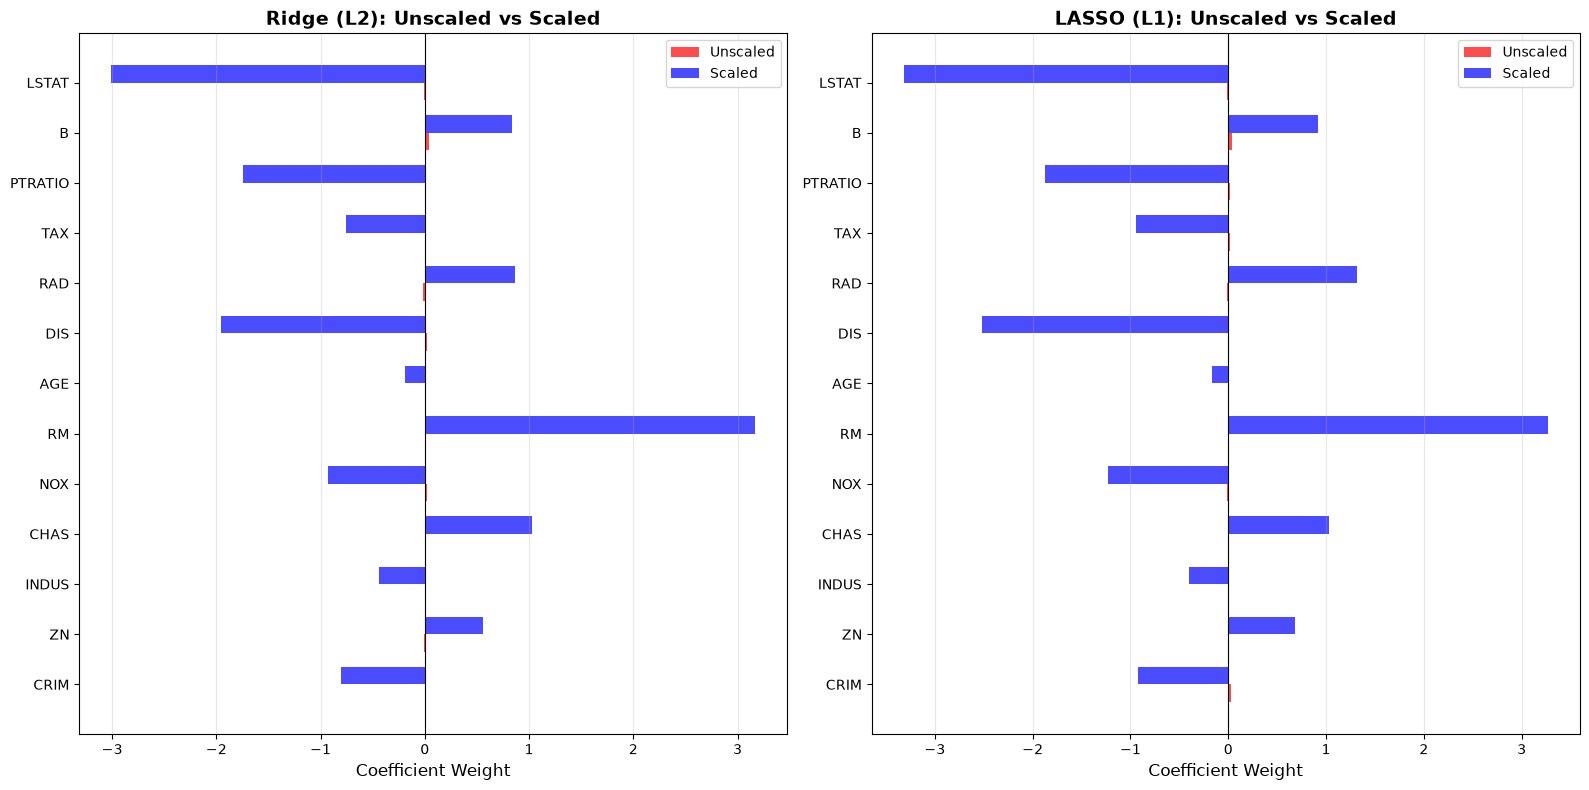

In [63]:
ridge_unscaled = ridge_wUnscale[1:].flatten()
ridge_scaled = ridge_wScale[1:].flatten()
lasso_unscaled = lasso_wUnscale[1:].flatten()
lasso_scaled = lasso_wScale[1:].flatten()

# Feature names
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
                 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

#PLOT 2 SUBPLOTS SIDE-BY-SIDE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# X-axis positions for features
x = np.arange(len(feature_names))
width = 0.35  # Bar width

# ============================================
# PLOT 1: RIDGE (Unscaled vs Scaled)
# ============================================
ax1.barh(x - width/2, ridge_unscaled, width, label='Unscaled', color='red', alpha=0.7)
ax1.barh(x + width/2, ridge_scaled, width, label='Scaled', color='blue', alpha=0.7)
ax1.set_yticks(x)
ax1.set_yticklabels(feature_names)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Coefficient Weight', fontsize=12)
ax1.set_title('Ridge (L2): Unscaled vs Scaled', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# ============================================
# PLOT 2: LASSO (Unscaled vs Scaled)
# ============================================
ax2.barh(x - width/2, lasso_unscaled, width, label='Unscaled', color='red', alpha=0.7)
ax2.barh(x + width/2, lasso_scaled, width, label='Scaled', color='blue', alpha=0.7)
ax2.set_yticks(x)
ax2.set_yticklabels(feature_names)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Coefficient Weight', fontsize=12)
ax2.set_title('LASSO (L1): Unscaled vs Scaled', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Lasso
Lasso (L1) is highly sensitive to feature scaling. When features have different units (ex - TAX=700, CRIM=0.1), Lasso unfairly penalizes the numerically larger features, shrinking their weights to near-zero (0.01), while numerically smaller features retain larger weights (0.04).

# Ridge
The gradient is multiplied by the weight itself. If TAX is huge (700), the model naturally makes its weight tiny (w ≈ 0.01).
Ridge automatically adjusts its penalty based on the size of the weight. Large-scale features get smaller weights, which triggers a smaller penalty. Small-scale features get larger weights, which triggers a larger penalty. Ridge naturally balances itself out!

In [ ]:
def train_batch_model(X_train,y_train,penalty,regrztion,epoch = 5000,learning_rate=0.001):
    N,d = X_train.shape
    weights = np.random.randn(d,1)*0.01
    loss_fun=[]
    for i in range(0,epoch):
        y_pred = X_train @ weights

        error = y_pred - y_train

        if regrztion == "ridge":
            loss,gradient = ridge(X_train,error,penalty,weights,N)

            #update
            weights = weights - learning_rate * gradient
            loss_fun.append(loss)

            if(i%50==0):
                print(f"At epoch {i}, the loss is {loss}")
                
        else: #lasso regularization
            loss,gradient = lasso(X_train,error,penalty,weights,N)
            
            #update
            weights = weights - learning_rate * gradient
            loss_fun.append(loss)

            if(i%50==0):
                print(f"At epoch {i}, the loss is {loss:.2f}")

    print("Training Complete!!!!")
    print(f"Weights with {regrztion} :: {weights.flatten()}")
    return weights, loss_fun


In [97]:
def complexity_curve(X_train, y_train, X_test, y_test, reg_type, penalty_range):
    """
    The complexity curve is the ultimate visualization of the bias-variance tradeoff. It answers:
    "What happens to my model as I increase regularization?"
    - Low penalty (left):The model is free to choose any weights. Model overfits (low train error, high test error).
    - High penalty (right):The regularization term dominates the loss and makes w≈0-->grad=very high.
        Model underfits (high train error, high test error).
    - Sweet spot (middle): Test error is minimized—this is your optimal regularization strength.
    - Also In case of Overfitting, we penalize large weights,Lambda and alpha controls how strict the penalty is.
    """

    train_errors = []
    test_errors = []
    best_test_error = np.inf
    best_penalty = None

    for pen in penalty_range:
        print(f"Training {reg_type} for penalty = {pen:.4f} ")
        weights,_ = train_batch_model(X_train,y_train,pen,reg_type,epoch = 5000,learning_rate=0.001)

        y_pred_train = X_train @ weights
        train_mse = np.mean((y_pred_train - y_train)**2)

        y_pred_test = X_test @ weights
        test_mse = np.mean((y_pred_test-y_test)**2)

        train_errors.append(train_mse)
        test_errors.append(test_mse)

        if test_mse < best_test_error:
            best_test_error = test_mse
            best_penalty=pen
        
    return np.array(train_errors), np.array(test_errors), best_penalty



In [98]:
#========= Penalty Ranges =================#
#Ridge Penalty (lambda) & Lasso Penalty (alpha)
ridge_penalties = np.logspace(-3,3,20)
lasso_penalties = np.logspace(-3,3,20)

#Cureve for Ridge
print("\n=== Ridge Complexity Curve ===")
ridge_train_err, ridge_test_err,ridge_best = complexity_curve(
    Xsc_train, y_train, Xsc_test, y_test,'ridge', ridge_penalties)

#Cureve for lasso
print("\n=== Lasso Complexity Curve ===")
lasso_train_err, lasso_test_err,lasso_best = complexity_curve(
    Xsc_train, y_train, Xsc_test, y_test,'lasso', lasso_penalties)


=== Ridge Complexity Curve ===
Training ridge for penalty = 0.0010 
At epoch 0, the loss is 597.6056450729606
At epoch 50, the loss is 472.8225283782699
At epoch 100, the loss is 384.7751610049964
At epoch 150, the loss is 316.8479031904955
At epoch 200, the loss is 262.5089866427496
At epoch 250, the loss is 218.44576931261037
At epoch 300, the loss is 182.53517003999747
At epoch 350, the loss is 153.21206196320855
At epoch 400, the loss is 129.24783959180624
At epoch 450, the loss is 109.65415329766164
At epoch 500, the loss is 93.62866029806874
At epoch 550, the loss is 80.51779449148701
At epoch 600, the loss is 69.78845246873179
At epoch 650, the loss is 61.00551504213056
At epoch 700, the loss is 53.81370706292357
At epoch 750, the loss is 47.92286827140577
At epoch 800, the loss is 43.09596516699355
At epoch 850, the loss is 39.13932360288842
At epoch 900, the loss is 35.89466628284448
At epoch 950, the loss is 33.23261919099569
At epoch 1000, the loss is 31.047414362101087
At 

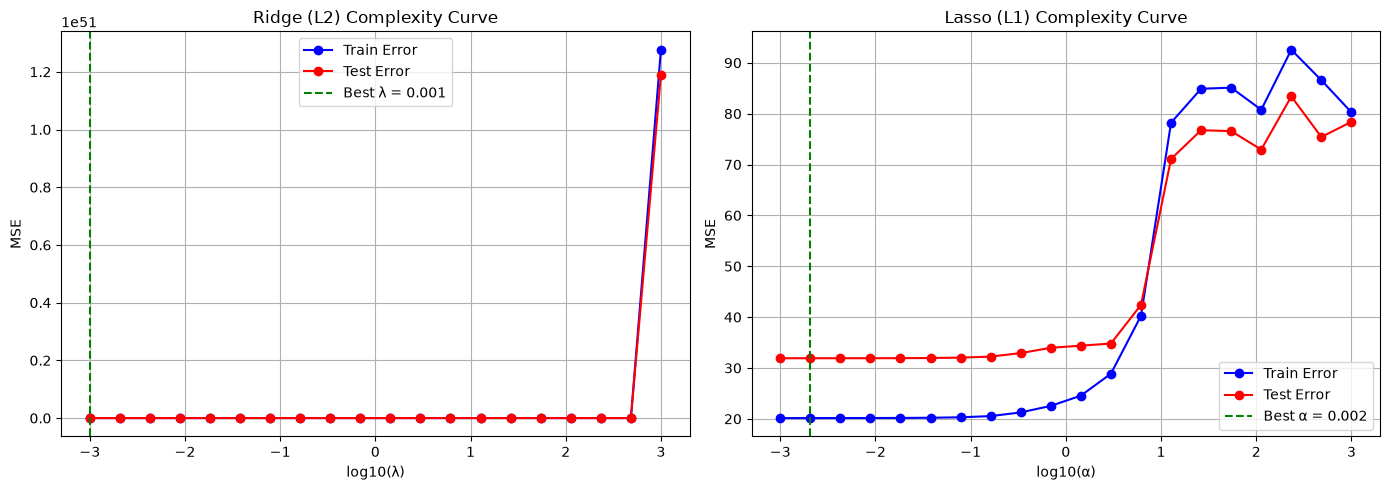

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Ridge Plot ---
ax1.plot(np.log10(ridge_penalties), ridge_train_err, 'b-o', label='Train Error')
ax1.plot(np.log10(ridge_penalties), ridge_test_err, 'r-o', label='Test Error')
ax1.axvline(np.log10(ridge_best), color='green', linestyle='--', label=f'Best λ = {ridge_best:.3f}')
ax1.set_xlabel('log10(λ)')
ax1.set_ylabel('MSE')
ax1.set_title('Ridge (L2) Complexity Curve')
ax1.legend()
ax1.grid(True)

# --- Lasso Plot ---
ax2.plot(np.log10(lasso_penalties), lasso_train_err, 'b-o', label='Train Error')
ax2.plot(np.log10(lasso_penalties), lasso_test_err, 'r-o', label='Test Error')
ax2.axvline(np.log10(lasso_best), color='green', linestyle='--', label=f'Best α = {lasso_best:.3f}')
ax2.set_xlabel('log10(α)')
ax2.set_ylabel('MSE')
ax2.set_title('Lasso (L1) Complexity Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [100]:

ridge_penalties_fixed = np.logspace(-5, 1, 20)  # 0.00001 to 0.1
lasso_penalties_fixed = np.logspace(-5, 0, 20)  # 0.00001 to 1.0

#complexity curve with new ranges
print("\n=== Ridge Complexity Curve (Zoomed In) ===")
ridge_train_err2, ridge_test_err2, ridge_best2 = complexity_curve(
    Xsc_train, y_train, Xsc_test, y_test, 'ridge', ridge_penalties_fixed)

print("\n=== Lasso Complexity Curve (Zoomed In) ===")
lasso_train_err2, lasso_test_err2, lasso_best2 = complexity_curve(
    Xsc_train, y_train, Xsc_test, y_test, 'lasso', lasso_penalties_fixed)


=== Ridge Complexity Curve (Zoomed In) ===
Training ridge for penalty = 0.0000 
At epoch 0, the loss is 597.6893027437186
At epoch 50, the loss is 472.72351527432306
At epoch 100, the loss is 384.64535874686817
At epoch 150, the loss is 316.72681035893544
At epoch 200, the loss is 262.4042424599136
At epoch 250, the loss is 218.35653866441703
At epoch 300, the loss is 182.45881033576296
At epoch 350, the loss is 153.1459280528673
At epoch 400, the loss is 129.18969639570136
At epoch 450, the loss is 109.60220627031558
At epoch 500, the loss is 93.5814940071556
At epoch 550, the loss is 80.47429985496919
At epoch 600, the loss is 69.74776275284708
At epoch 650, the loss is 60.966953809985995
At epoch 700, the loss is 53.77674692126685
At epoch 750, the loss is 47.887098462315784
At epoch 800, the loss is 43.06106617952004
At epoch 850, the loss is 39.10504729723174
At epoch 900, the loss is 35.86082032908509
At epoch 950, the loss is 33.19905488253519
At epoch 1000, the loss is 31.0140

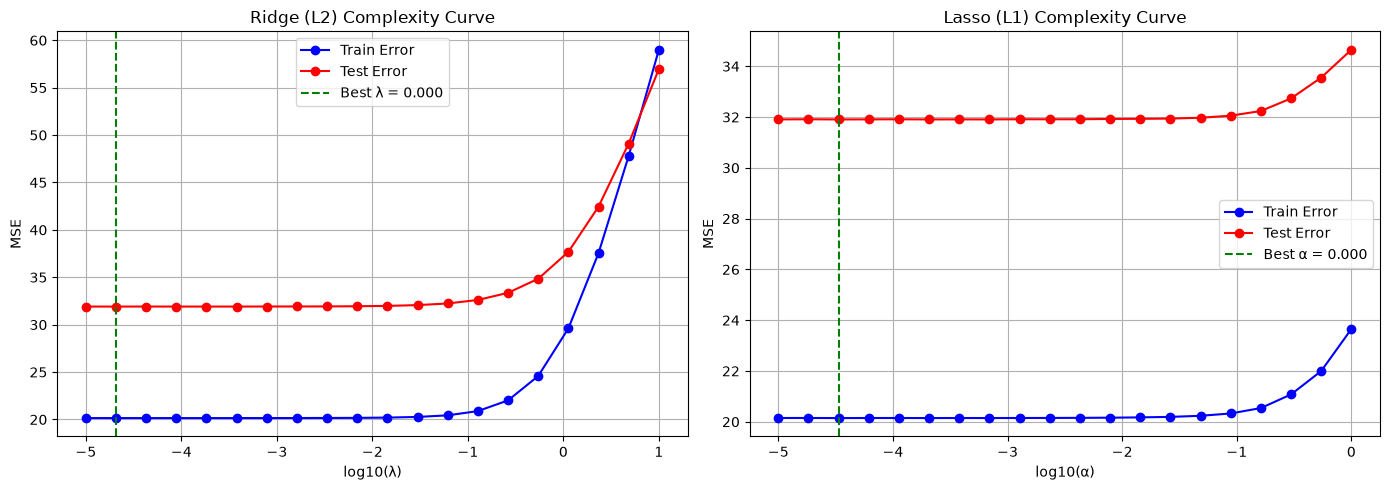

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Ridge Plot ---
ax1.plot(np.log10(ridge_penalties_fixed), ridge_train_err2, 'b-o', label='Train Error')
ax1.plot(np.log10(ridge_penalties_fixed), ridge_test_err2, 'r-o', label='Test Error')
ax1.axvline(np.log10(ridge_best2), color='green', linestyle='--', label=f'Best λ = {ridge_best2:.3f}')
ax1.set_xlabel('log10(λ)')
ax1.set_ylabel('MSE')
ax1.set_title('Ridge (L2) Complexity Curve')
ax1.legend()
ax1.grid(True)

# --- Lasso Plot ---
ax2.plot(np.log10(lasso_penalties_fixed), lasso_train_err2, 'b-o', label='Train Error')
ax2.plot(np.log10(lasso_penalties_fixed), lasso_test_err2, 'r-o', label='Test Error')
ax2.axvline(np.log10(lasso_best2), color='green', linestyle='--', label=f'Best α = {lasso_best2:.3f}')
ax2.set_xlabel('log10(α)')
ax2.set_ylabel('MSE')
ax2.set_title('Lasso (L1) Complexity Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()